# Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import seaborn as sns
from bs4 import BeautifulSoup
from IPython.display import display

In [2]:
df1 = pd.read_csv('../csv/X_train_update.csv')
df2 = pd.read_csv('../csv/Y_train_CVw08PX.csv')

df = pd.concat([df1, df2], axis=1)
df = df.drop(['Unnamed: 0'], axis=1)
df["image_filename"] = "image_" + df["imageid"].astype(str) + "_product_" + df["productid"].astype(str) + ".jpg"

display(df.info())
df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 84916 entries, 0 to 84915
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   designation     84916 non-null  str  
 1   description     55116 non-null  str  
 2   productid       84916 non-null  int64
 3   imageid         84916 non-null  int64
 4   prdtypecode     84916 non-null  int64
 5   image_filename  84916 non-null  str  
dtypes: int64(3), str(3)
memory usage: 56.2 MB


None

,designation,description,productid,imageid,prdtypecode,image_filename
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046,10,image_1263597046_product_3804725264.jpg
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237,2280,image_1008141237_product_436067568.jpg
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978,50,image_938777978_product_201115110.jpg
3,Peluche Donald - Europe - Disneyland 2000 (Mar...,NaN,50418756,457047496,1280,image_457047496_product_50418756.jpg
4,La Guerre Des Tuques,Luc a des id&eacute;es de grandeur. Il veut or...,278535884,1077757786,2705,image_1077757786_product_278535884.jpg


## Quelques chiffres

In [ ]:
#######################################################################
# Squelette du résumé des analyses de données textuelles
#######################################################################

resume = pd.DataFrame(  index=[ "Lignes totales analysées",
                                "Valeurs manquantes",
                                "Doublons",
                                "Nombre moyen de mots",
                                "Textes identiques utilisés pour plusieurs catégories",
                                "Présence de balises / entités HTML",
                                "Encodage cassé",
                                "Présence d'URLs",
                                "Texte très court <= 3 tokens"],
                        columns=["Designation", "pct_designation",  "Description", "pct_description"])

#######################################################################
# Lignes remplies facilement avec les méthodes pandas basiques
#######################################################################

resume.loc["Lignes totales analysées"] = [df.shape[0], "", df.shape[0], ""]

resume.loc["Valeurs manquantes"] = [df['designation'].isna().sum(),  
                                    round(df['designation'].isna().sum() / df.shape[0] * 100, 2), 
                                    df['description'].isna().sum(), 
                                    round(df['description'].isna().sum() / df.shape[0] * 100, 2)]


resume.loc["Doublons"] = [df[df['designation'].notna() & df['designation'].duplicated(keep=False)].shape[0], 
                          round(df[df['designation'].notna() & df['designation'].duplicated(keep=False)].shape[0] / df.shape[0] * 100, 2),
                          df[df['description'].notna() & df['description'].duplicated(keep=False)].shape[0], 
                          round(df[df['description'].notna() & df['description'].duplicated(keep=False)].shape[0] / df.dropna().shape[0] * 100, 2)]

resume.loc["Nombre moyen de mots"] = [df['designation'].dropna().apply(lambda x: len(x.split())).mean(), 
                                      round(df['designation'].dropna().apply(lambda x: len(x.split())).mean() / df.shape[0] * 100, 2),
                                      df['description'].dropna().apply(lambda x: len(x.split())).mean(), 
                                      round(df['description'].dropna().apply(lambda x: len(x.split())).mean() / df.dropna().shape[0] * 100, 2)]



resume.loc["Texte très court <= 3 tokens"] = [df['designation'].dropna().apply(lambda x: len(x.split()) <= 3).sum(), 
                                              round(df['designation'].dropna().apply(lambda x: len(x.split()) <= 3).sum() / df.shape[0] * 100, 2),
                                              df['description'].dropna().apply(lambda x: len(x.split()) <= 3).sum(),
                                              round(df['description'].dropna().apply(lambda x: len(x.split()) <= 3).sum() / df.dropna().shape[0] * 100, 2)]  


#######################################################################
# Lignes nécessitant un code plus complexe
#######################################################################

# Textes identiques utilisés pour plusieurs catégories

descriptions_multi_categories = df.dropna(subset=["description", "prdtypecode"]).groupby("description")["prdtypecode"].nunique().loc[lambda s: s > 1]

designation_multi_categories = df.dropna(subset=["designation", "prdtypecode"]).groupby("designation")["prdtypecode"].nunique().loc[lambda s: s > 1]

nb_designation_multi_categories = len(designation_multi_categories)
nb_description_multi_categories = len(descriptions_multi_categories)

resume.loc["Textes identiques utilisés pour plusieurs catégories"] = [  nb_designation_multi_categories,
                                                                        round(nb_designation_multi_categories / df.shape[0] * 100, 2),
                                                                        nb_description_multi_categories,
                                                                        round(nb_description_multi_categories / df.dropna().shape[0] * 100, 2)]

# Présence de balises / entités HTML
def contient_balise_html(x):
    if pd.isna(x):
        return False
    return bool(BeautifulSoup(str(x), "html.parser").find())

def contient_entite_html(x):
    if pd.isna(x):
        return False
    
    x = str(x)
    
    # détecte &eacute; &#39; &nbsp; &#x27; etc.
    return bool(re.search(r"&(?:[a-zA-Z]+|#[0-9]+|#x[0-9a-fA-F]+);", x))

def contient_balise_ou_entite_html(x):
    return contient_balise_html(x) or contient_entite_html(x)

html_designation = df["designation"].apply(contient_balise_ou_entite_html).sum()
html_description = df["description"].apply(contient_balise_ou_entite_html).sum()

resume.loc["Présence de balises / entités HTML"] = [html_designation,
                                                    round(html_designation / df.shape[0] * 100, 2),
                                                    html_description,
                                                    round(html_description / df.dropna().shape[0] * 100, 2)]

# Encodage cassé
def contient_encodage_casse(x):
    if pd.isna(x):
        return False
    
    x = str(x)
    
    motifs_encodage_casse = r"Ã|Â|â€|�|à¢|ã"
    
    return bool(re.search(motifs_encodage_casse, x, flags=re.IGNORECASE))


encodage_casse_designation = df["designation"].apply(contient_encodage_casse).sum()
encodage_casse_description = df["description"].apply(contient_encodage_casse).sum()

resume.loc["Encodage cassé"] =[ encodage_casse_designation,
                                round(encodage_casse_designation / df.shape[0] * 100, 2),
                                encodage_casse_description,
                                round(encodage_casse_description / df.dropna().shape[0] * 100, 2)]

# Présence d'URLs
def contient_url(x):
    if pd.isna(x):
        return False
    
    x = str(x)
    
    motifs_url = r"https?://\S+|www\.\S+"
    
    return bool(re.search(motifs_url, x, flags=re.IGNORECASE))


url_designation = df["designation"].apply(contient_url).sum()
url_description = df["description"].apply(contient_url).sum()

resume.loc["Présence d'URLs"] = [url_designation,
                                 round(url_designation / df.shape[0] * 100, 2),
                                 url_description,
                                 round(url_description / df.dropna().shape[0] * 100, 2)]

#######################################################################
# Sortie du résumé des analyses de données textuelles
#######################################################################

class_counts = df["prdtypecode"].value_counts().sort_values(ascending=False)
print(f"Le dataset contient {len(df)} lignes réparties sur {len(class_counts)} classes différentes.")

display(resume)

print(f"Enfin, on observe que {df[df['description'] == df['designation']].shape[0]} description ssont une copie de la désignation.")





Le dataset contient 84916 lignes réparties sur 27 classes différentes.


,Designation,pct_designation,Description,pct_description
Lignes totales analysées,84916,,84916,
Valeurs manquantes,0,0.0,29800,35.09
Doublons,4073,4.8,10611,19.25
Nombre moyen de mots,11.557374,0.01,123.510959,0.22
Textes identiques utilisés pour plusieurs catégories,145,0.17,270,0.49
Présence de balises / entités HTML,990,1.17,40119,72.79
Encodage cassé,2938,3.46,10849,19.68
Présence d'URLs,0,0.0,202,0.37
Texte très court <= 3 tokens,2,0.0,502,0.91


Enfin, on observe que 179 description ssont une copie de la désignation.


## Analyses Graphiques

### Descriptions manquantes

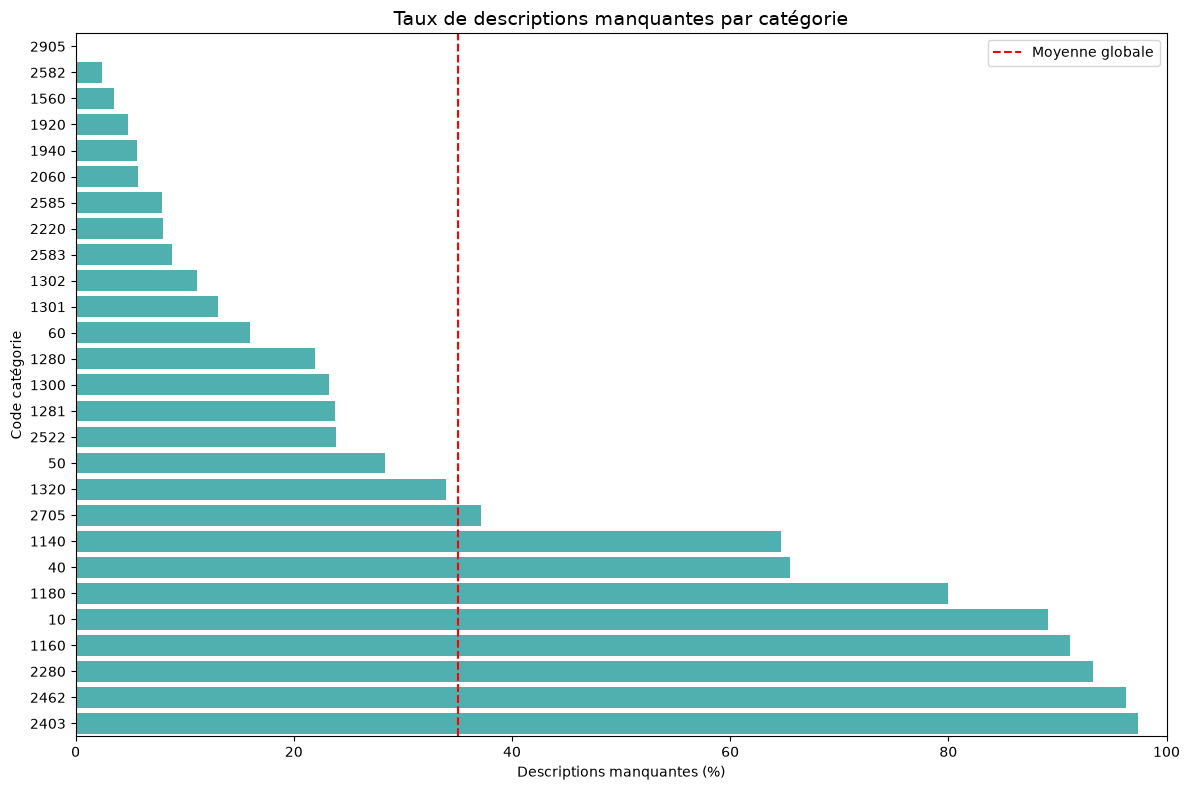

Le test du Chi² compare deux variables qualitatives :


,Variable,Type
0,prdtypecode,catégorie produit
1,description_absente,booléen : description absente ou présente



Hypothèses :
H0 : La catégorie produit et l'absence de description sont indépendantes.
H1 : La catégorie produit et l'absence de description ne sont pas indépendantes.

Un Chi² à 43757.77 est très élevé, ce qui indique un écart important entre les effectifs observés et les effectifs attendus si tout était indépendant
Mais le Chi² seul ne suffit pas à interpréter la force de la dépendance entre les deux variables, surtout avec un grand nombre d'observations.

une p-value à 0.0000e+00, donc non nulle mais très proche de 0, ce qui permet de rejeter l'hypothèse nulle d'indépendance entre les deux variables.

Un V de Cramer à 0.718, donc > à 0.5, indique une association très forte entre la catégorie produit et l'absence de description


In [26]:

df["description_absente"] = (df["description"].isna()) | (df["description"].astype(str).str.strip().eq(""))

# Agrégation
desc_missing = df.groupby("prdtypecode").agg(   nb_produits=("prdtypecode", "size"),
                                                taux_description_absente=("description_absente", "mean")).reset_index()

desc_missing["taux_description_absente_pct"] = desc_missing["taux_description_absente"] * 100
desc_missing["prdtypecode"] = desc_missing["prdtypecode"].astype(str)
desc_missing = desc_missing.sort_values("taux_description_absente_pct")

# Calcul du Chi²
contingence = pd.crosstab(df["prdtypecode"], df["description_absente"])
chi2, p_value, dof, expected = stats.chi2_contingency(contingence)


n = contingence.to_numpy().sum()
v_cramer = math.sqrt(chi2 / (n * (min(contingence.shape) - 1)))

# Graphique
fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=desc_missing,
    x="taux_description_absente_pct",
    y=desc_missing["prdtypecode"],
    ax=ax,
    color="#40BFBF"
)

ax.axvline(
    df["description_absente"].mean() * 100,
    linestyle="--",
    label="Moyenne globale",
    color="red"
)

ax.set_title("Taux de descriptions manquantes par catégorie", fontsize=14)
ax.set_xlabel("Descriptions manquantes (%)")
ax.set_ylabel("Code catégorie")
ax.set_xlim(0, 100)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


# Test du Chi²
print("Le test du Chi² compare deux variables qualitatives :")
display(pd.DataFrame({
    "Variable": ["prdtypecode", "description_absente"],
    "Type": ["catégorie produit", "booléen : description absente ou présente"]
}))

print("\nHypothèses :")
print("H0 : La catégorie produit et l'absence de description sont indépendantes.")
print("H1 : La catégorie produit et l'absence de description ne sont pas indépendantes.")
print()



print(f"Un Chi² à {chi2:.2f} est très élevé, ce qui indique un écart important entre les effectifs observés et les effectifs attendus si tout était indépendant")
print("Mais le Chi² seul ne suffit pas à interpréter la force de la dépendance entre les deux variables, surtout avec un grand nombre d'observations.")
print()
print(f"une p-value à {p_value:.4e}, donc non nulle mais très proche de 0, ce qui permet de rejeter l'hypothèse nulle d'indépendance entre les deux variables.")
print()
print(f"Un V de Cramer à {v_cramer:.3f}, donc > à 0.5, indique une association très forte entre la catégorie produit et l'absence de description")

### Longueur du texte par catégorie

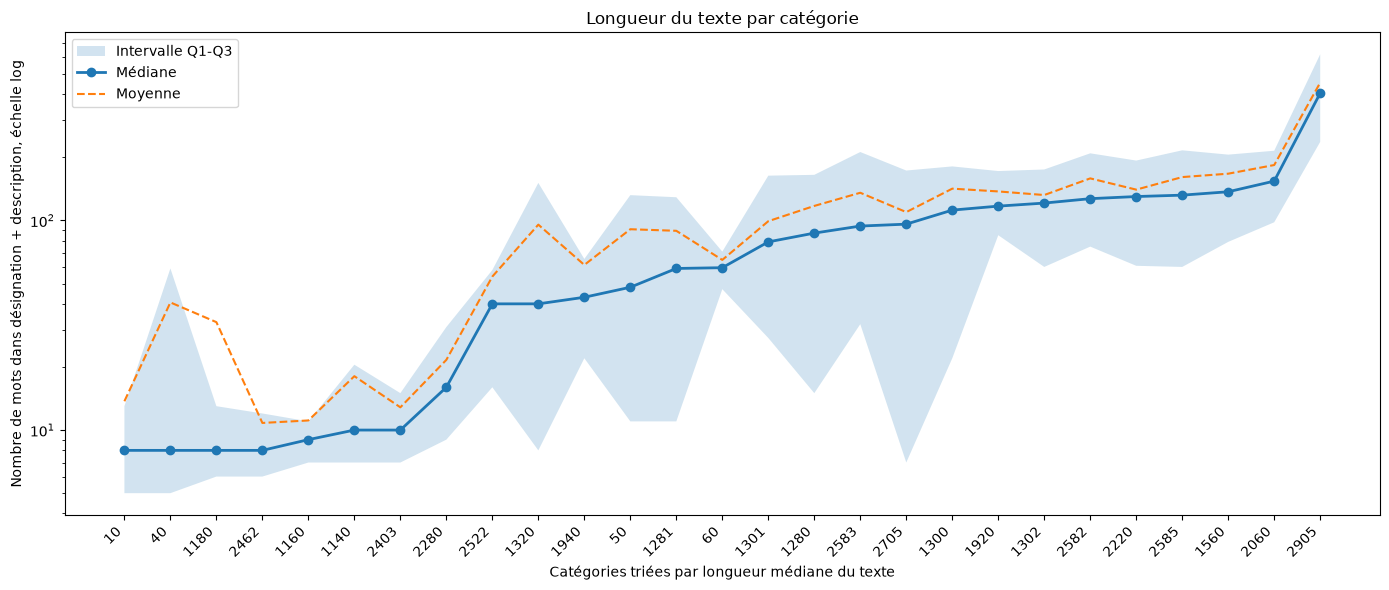

In [29]:
# Texte complet
df["texte_complet"] = (
    df["designation"].fillna("") + " " + df["description"].fillna("")
).str.strip()

df["nb_mots_texte"] = df["texte_complet"].str.findall(r"\b\w+\b").str.len()

# Statistiques par catégorie
length_stats = (
    df.groupby("prdtypecode")["nb_mots_texte"]
    .agg(
        q1=lambda x: x.quantile(0.25),
        mediane="median",
        q3=lambda x: x.quantile(0.75),
        moyenne="mean",
        nb="size"
    )
    .reset_index()
    .sort_values("mediane")
)

# Positions x
x = np.arange(len(length_stats))

fig, ax = plt.subplots(figsize=(14, 6))

# Zone interquartile Q1-Q3
ax.fill_between(
    x,
    length_stats["q1"],
    length_stats["q3"],
    alpha=0.2,
    label="Intervalle Q1-Q3"
)

# Courbe de la médiane
ax.plot(
    x,
    length_stats["mediane"],
    marker="o",
    linewidth=2,
    label="Médiane"
)

# Optionnel : moyenne en pointillé
ax.plot(
    x,
    length_stats["moyenne"],
    linestyle="--",
    linewidth=1.5,
    label="Moyenne"
)

ax.set_xticks(x)
ax.set_xticklabels(length_stats["prdtypecode"].astype(str), rotation=45, ha="right")

ax.set_yscale("log")

ax.set_title("Longueur du texte par catégorie")
ax.set_xlabel("Catégories triées par longueur médiane du texte")
ax.set_ylabel("Nombre de mots dans désignation + description, échelle log")

# Légende en haut à gauche
ax.legend(loc="upper left")



plt.tight_layout()
plt.show()

### Distribution de la longueur des textes

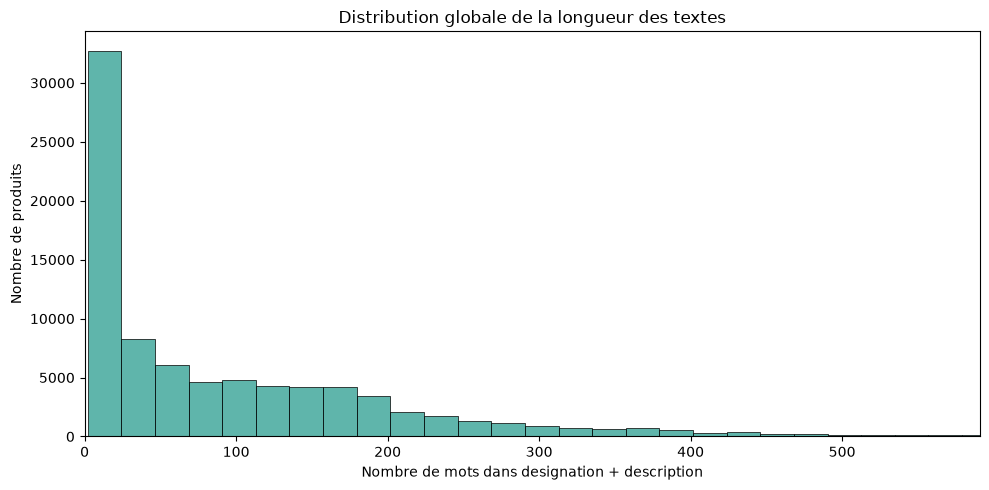

In [33]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="nb_mots_texte",
    bins=100,
    color="#2A9D8F"
)

plt.xlim(0, df["nb_mots_texte"].quantile(0.99))

plt.title("Distribution globale de la longueur des textes")
plt.xlabel("Nombre de mots dans designation + description")
plt.ylabel("Nombre de produits")

plt.tight_layout()
plt.show()

### Distribution des catégories

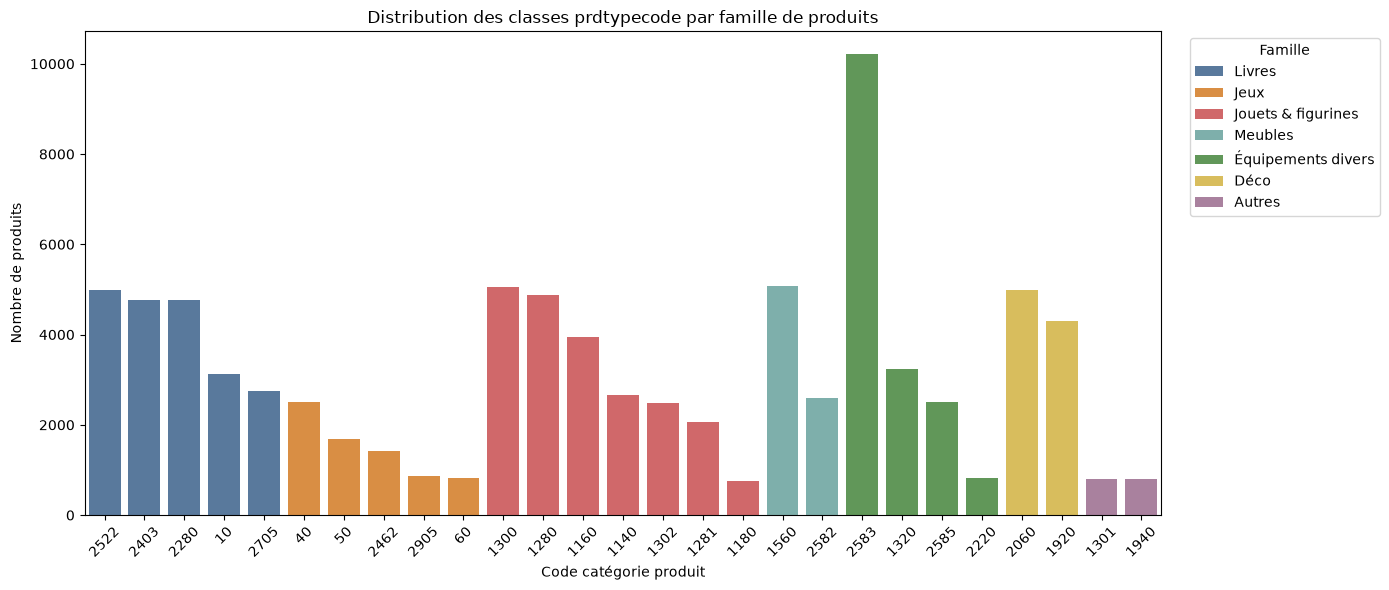

In [34]:
# Mapping code -> famille
code_to_famille = {
    10: "Livres",
    2280: "Livres",
    2403: "Livres",
    2522: "Livres",
    2705: "Livres",

    40: "Jeux",
    50: "Jeux",
    60: "Jeux",
    2462: "Jeux",
    2905: "Jeux",

    1140: "Jouets & figurines",
    1160: "Jouets & figurines",
    1180: "Jouets & figurines",
    1280: "Jouets & figurines",
    1281: "Jouets & figurines",
    1300: "Jouets & figurines",
    1302: "Jouets & figurines",

    1560: "Meubles",
    2582: "Meubles",

    1320: "Équipements divers",
    2220: "Équipements divers",
    2583: "Équipements divers",
    2585: "Équipements divers",

    1920: "Déco",
    2060: "Déco",

    1301: "Autres",
    1940: "Autres"
}

df["famille_produit"] = df["prdtypecode"].map(code_to_famille)

# Comptage des produits par classe
class_counts = (
    df.groupby(["prdtypecode", "famille_produit"])
    .size()
    .reset_index(name="nombre_produits")
)

# Ordre des familles
ordre_familles = [
    "Livres",
    "Jeux",
    "Jouets & figurines",
    "Meubles",
    "Équipements divers",
    "Déco",
    "Autres"
]

class_counts["famille_produit"] = pd.Categorical(
    class_counts["famille_produit"],
    categories=ordre_familles,
    ordered=True
)

# Tri par famille puis par effectif décroissant
class_counts = class_counts.sort_values(
    ["famille_produit", "nombre_produits"],
    ascending=[True, False]
)

# Palette par famille
palette_familles = {
    "Livres": "#4E79A7",
    "Jeux": "#F28E2B",
    "Jouets & figurines": "#E15759",
    "Meubles": "#76B7B2",
    "Équipements divers": "#59A14F",
    "Déco": "#EDC948",
    "Autres": "#B07AA1"
}

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=class_counts,
    x=class_counts["prdtypecode"].astype(str),
    y="nombre_produits",
    hue="famille_produit",
    dodge=False,
    palette=palette_familles
)

plt.title("Distribution des classes prdtypecode par famille de produits")
plt.xlabel("Code catégorie produit")
plt.ylabel("Nombre de produits")
plt.xticks(rotation=45)
plt.legend(title="Famille", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()